In [1]:
# Import the BFSI analytics stack 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# Load the Kaggle dataset
# SeriousDlqin2yrs is our target (NPA/Default)
df = pd.read_csv('../data/cs-training.csv').drop('Unnamed: 0', axis=1)

print(f"Dataset Loaded: {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

Dataset Loaded: 150000 rows and 11 columns.


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [2]:
# 1. Define Features (X) and Target (y)
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

# 2. Handle Missing Values 
# We use 'median' because financial data often has outliers (rich customers)
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# 3. Train/Test Split
# We use 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

print("Data Cleaning and Splitting Complete.")

Data Cleaning and Splitting Complete.


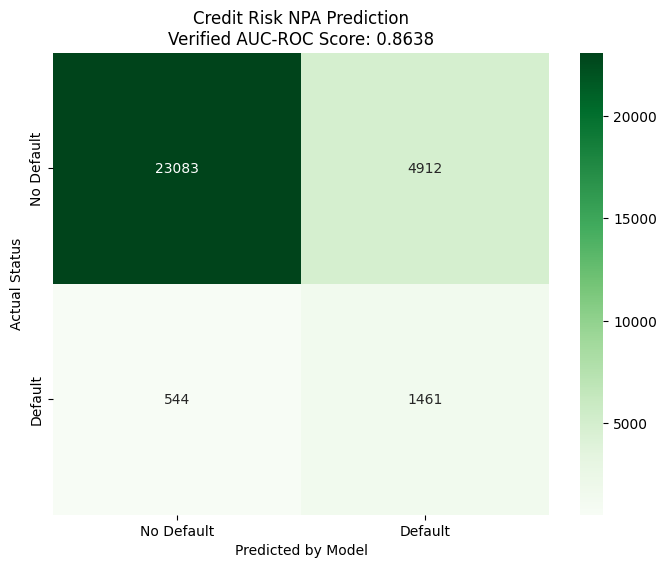

Final AUC-ROC Score: 0.8638


In [3]:
# 1. Initialize and Train the Random Forest
# We use 'balanced' class weights because 'Defaults' are rare in banking
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# 2. Calculate the AUC-ROC Score 
y_pred_proba = model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_pred_proba)

# 3. Generate the Confusion Matrix
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# 4. Professional Visualization for Stakeholders [cite: 27]
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Default', 'Default'], 
            yticklabels=['No Default', 'Default'])
plt.title(f'Credit Risk NPA Prediction\nVerified AUC-ROC Score: {auc_score:.4f}')
plt.xlabel('Predicted by Model')
plt.ylabel('Actual Status')
plt.show()

print(f"Final AUC-ROC Score: {auc_score:.4f}")